# Find optimal parameters for UMAP

In [15]:
### Imports
from rail.core.data import DataStore
from rail.core.stage import RailStage
from rail.core.data import PqHandle

import numpy as np
import h5py
import tables_io

from UMAPEstimator import UMAPEstimator

from rail.evaluation.dist_to_point_evaluator import DistToPointEvaluator
import optuna

# Specify paths and parameters

In [2]:
### Specify path to noisy catalog
noisy_catalog_path = '/Users/leo/Projects/LBG_cosmology/simulated_catalogs/integrated_catalog_23apr26_noised_19Jun26.pq'

### Specify path to output photometry
import time
date = time.strftime('%d%b%y', time.localtime())
photoz_path = noisy_catalog_path.split('.pq')[0] + f'_UMAPphotoz_{date}.pq'

# Split data into training and validation

In [3]:
training_fraction = 0.8


metric            = "manhattan_weighted_linear"
seed              = 42

In [4]:
data = tables_io.read(noisy_catalog_path)

data_cut = int(1e4)
# data_cut = -1
data = data[:data_cut]

training_indices = np.zeros(len(data), dtype = bool)
training_indices[np.random.choice(len(data), size = int(training_fraction * len(data)),
                 replace = False)] = True

bands = [key for key in data.keys() if (not key.endswith('_err')) & (key != 'Roman_F146')]
error_bands = [key for key in data.keys() if key.endswith('_err')]

validation_data = data[~training_indices]
training_data   = data[training_indices]

column_list None


In [5]:
photometry_bands = [key for key in training_data.keys()\
                        if (not key.endswith('_err')) and (key != 'Roman_F146')]
phot_error_bands = [f"{key}_err" for key in photometry_bands]

In [6]:
redshift_filepath = '/Users/leo/Projects/LBG_cosmology/surveys/pop-cosmos/mock_catalog/mock_catalog_Ch1_26.h5'
redshift          = h5py.File(redshift_filepath)['sfh_parameters'][:, -1]

training_redshift   = redshift[:data_cut][training_indices]
validation_redshift = redshift[:data_cut][~training_indices]

# Instantiate and run RAIL stage

In [7]:
RailStage.data_store = DataStore()

stage = UMAPEstimator.make_stage(
    name = "UMAP_informer",
    
    ambient_metric_umap = metric,
    
    seed = seed
)

stage.set_data("training_photometry", data = training_data[photometry_bands])
stage.set_data("training_phot_error", data = training_data[phot_error_bands])
stage.set_data("training_redshift",   data = training_redshift)

Inserting handle into data store.  training_photometry: None, UMAP_informer
Inserting handle into data store.  training_phot_error: None, UMAP_informer
Inserting handle into data store.  training_redshift: None, UMAP_informer


array([0.09602419, 0.13377383, 0.07222292, ..., 0.11307532, 0.16026022,
       0.1396269 ], shape=(8000,), dtype=float32)

# Inform the estimator

In [8]:
stage.UMAP_informer()

/Users/leo/miniforge3/envs/RAIL/lib/python3.14/site-packages/umap/umap_.py:1857: UserWarning: custom distance metric does not return gradient; inverse_transform will be unavailable. To enable using inverse_transform method, define a distance function that returns a tuple of (distance [float], gradient [np.array])
  warn(
/Users/leo/miniforge3/envs/RAIL/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Inserting handle into data store.  informed_reducer_UMAP_informer: inprogress_informed_reducer_UMAP_informer.pkl, UMAP_informer
Inserting handle into data store.  informed_embedding_UMAP_informer: inprogress_informed_embedding_UMAP_informer.pq, UMAP_informer
Inserting handle into data store.  informed_kNN_regressor_UMAP_informer: inprogress_informed_kNN_regressor_UMAP_informer.pkl, UMAP_informer


# Estimate redshifts

In [9]:
stage.set_data("estimation_photometry", data = validation_data[photometry_bands])
stage.set_data("estimation_phot_error", data = validation_data[phot_error_bands])
stage.UMAP_estimator()

Inserting handle into data store.  estimation_photometry: None, UMAP_informer
Inserting handle into data store.  estimation_phot_error: None, UMAP_informer
Inserting handle into data store.  estimated_embedding_UMAP_informer: inprogress_estimated_embedding_UMAP_informer.pq, UMAP_informer
Inserting handle into data store.  estimated_photoz_medians_UMAP_informer: inprogress_estimated_photoz_medians_UMAP_informer.pq, UMAP_informer
Inserting handle into data store.  estimated_photoz_pdfs_UMAP_informer: inprogress_estimated_photoz_pdfs_UMAP_informer.hdf5, UMAP_informer


In [10]:
estimated_photoz_pdfs = stage.get_handle('estimated_photoz_pdfs').data
estimated_photoz_medians = stage.get_handle('estimated_photoz_medians').data

# Evaluate

# Plot redshifts

In [11]:
import matplotlib.pyplot as plt
plt.style.use('/Users/leo/Projects/LBG_cosmology/code/umap_nz_cal.mplstyle')

Text(0, 0.5, 'Density')

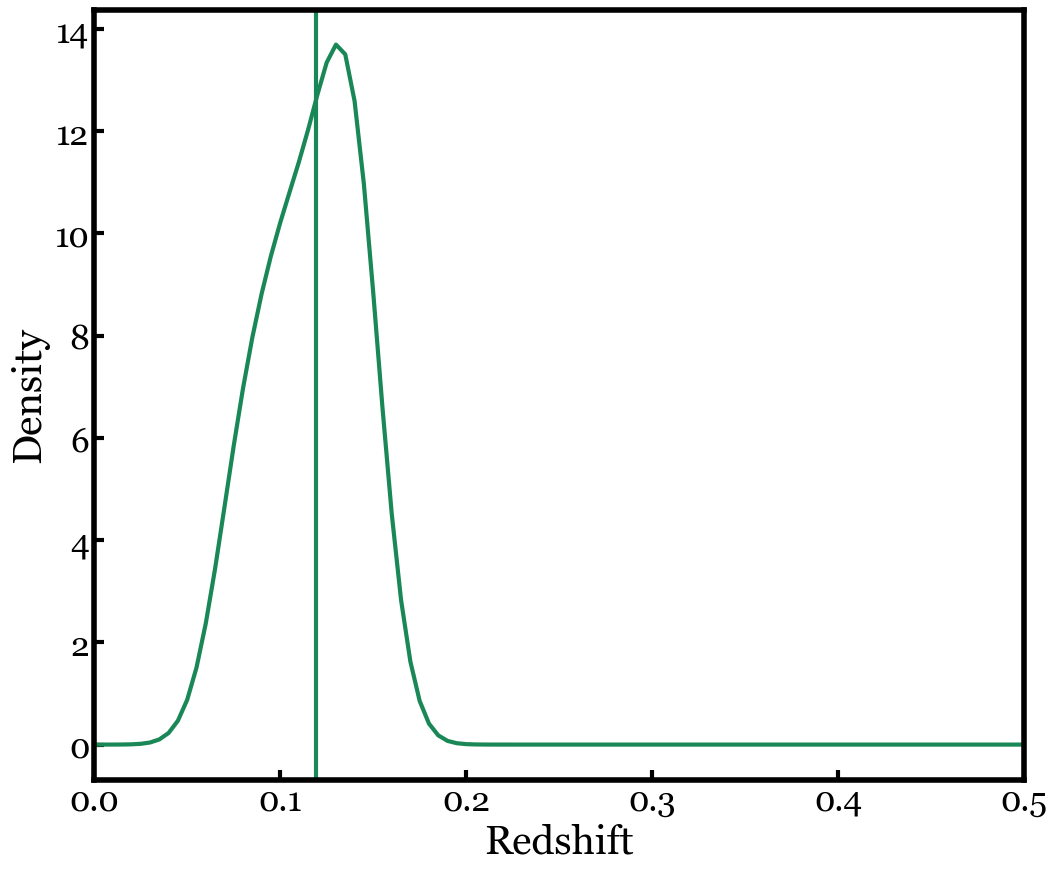

In [13]:
fig = plt.figure()
ax = fig.add_subplot()
ax.set_xlim(0, .5)

index = 0

estimated_photoz_pdfs.plot(index, axes = ax)
ax.axvline(estimated_photoz_medians.values[index])

ax.set_xlabel('Redshift')
ax.set_ylabel('Density')

In [ ]:
RailStage.data_store = DataStore()

stage = UMAPEstimator.make_stage(
    name = "UMAP_informer",
    
    ambient_metric_umap = metric,
    
    seed = seed
)

stage.set_data("training_photometry", data = training_data[photometry_bands])
stage.set_data("training_phot_error", data = training_data[phot_error_bands])
stage.set_data("training_redshift",   data = training_redshift)

Inserting handle into data store.  training_photometry: None, UMAP_informer
Inserting handle into data store.  training_phot_error: None, UMAP_informer
Inserting handle into data store.  training_redshift: None, UMAP_informer


array([0.1092879 , 0.09602419, 0.13377383, ..., 0.10793547, 0.1738595 ,
       0.15642053], shape=(1599999,), dtype=float32)

# Inform the estimator

In [ ]:
stage.UMAP_informer()

/Users/leo/miniforge3/envs/RAIL/lib/python3.14/site-packages/umap/umap_.py:1857: UserWarning: custom distance metric does not return gradient; inverse_transform will be unavailable. To enable using inverse_transform method, define a distance function that returns a tuple of (distance [float], gradient [np.array])
  warn(
/Users/leo/miniforge3/envs/RAIL/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


# Estimate redshifts

In [ ]:
stage.set_data("estimation_photometry", data = validation_data[photometry_bands])
stage.set_data("estimation_phot_error", data = validation_data[phot_error_bands])
stage.UMAP_estimator()

Inserting handle into data store.  estimation_photometry: None, UMAP_informer
Inserting handle into data store.  estimation_phot_error: None, UMAP_informer
Inserting handle into data store.  estimated_embedding_UMAP_informer: inprogress_estimated_embedding_UMAP_informer.pq, UMAP_informer
Inserting handle into data store.  estimated_photoz_medians_UMAP_informer: inprogress_estimated_photoz_medians_UMAP_informer.pq, UMAP_informer
Inserting handle into data store.  estimated_photoz_pdfs_UMAP_informer: inprogress_estimated_photoz_pdfs_UMAP_informer.hdf5, UMAP_informer


In [ ]:
estimated_photoz_pdfs = stage.get_handle('estimated_photoz_pdfs').data
estimated_photoz_medians = stage.get_handle('estimated_photoz_medians').data

# Evaluate

# Plot redshifts

In [ ]:
import matplotlib.pyplot as plt
plt.style.use('/Users/leo/Projects/LBG_cosmology/code/umap_nz_cal.mplstyle')

Text(0, 0.5, 'Density')

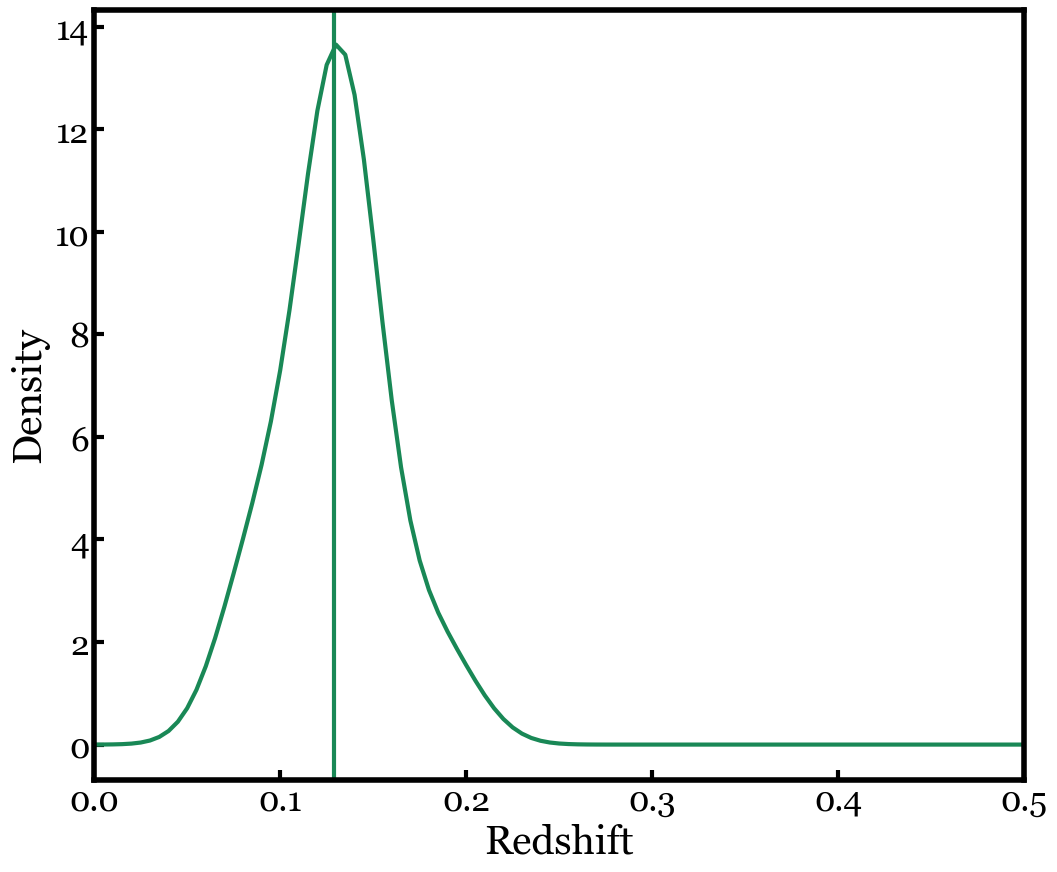

In [ ]:
fig = plt.figure()
ax = fig.add_subplot()
ax.set_xlim(0, .5)

index = 6500

estimated_photoz_pdfs.plot(index, axes = ax)
ax.axvline(estimated_photoz_medians.values[index])

ax.set_xlabel('Redshift')
ax.set_ylabel('Density')

In [16]:
validation_redshift

array([0.1092879 , 0.17016256, 0.12323937, ..., 0.06261387, 0.14615223,
       0.16045725], shape=(2000,), dtype=float32)

In [ ]:
evaluator = DistToPointEvaluator.make_stage(
    name = "DistToPointEvaluator",
    metrics = ["cdeloss"],
    reference_dictionary_key = "true_z",
    hdf5_groupname = "",
    metric_integration_limits = [0, 3],
    dx = 0.001,
    output_mode = "return"
)

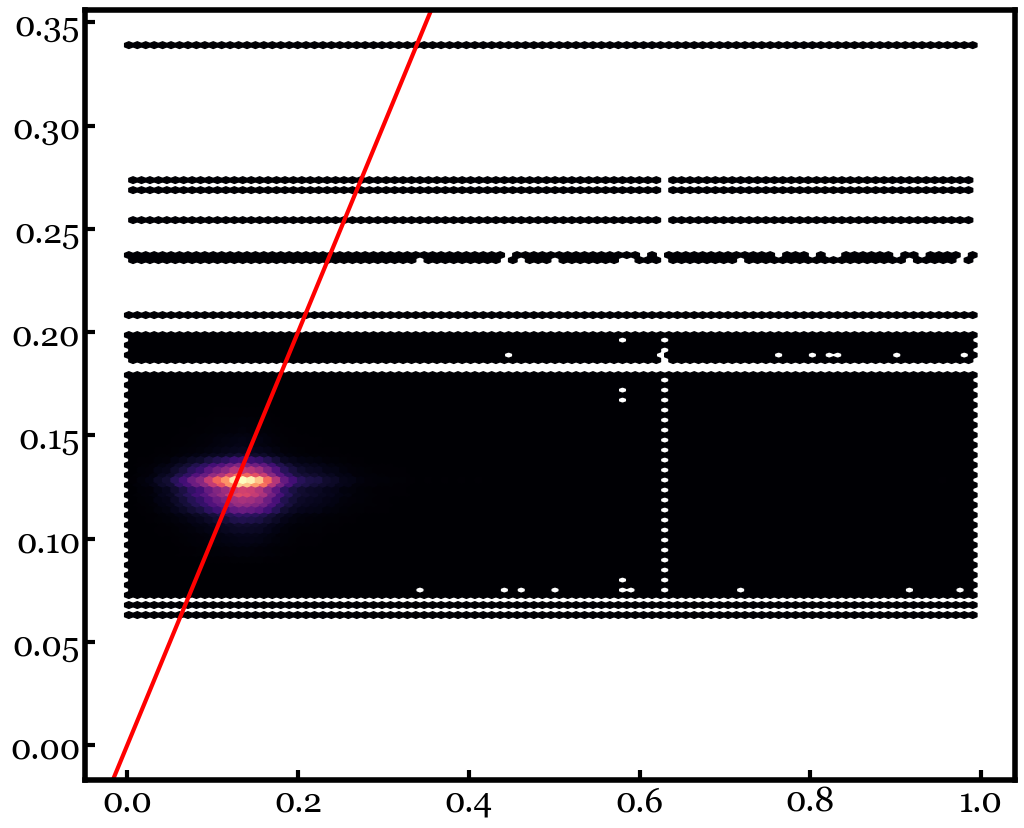

In [ ]:
fig = plt.figure()
ax = fig.add_subplot()


ax.hexbin(validation_redshift, estimated_photoz_medians,
          mincnt = 1)
ax.axline((0, 0), slope = 1, color = 'red')

In [ ]:
def sigma_NMAD(estimated_z, true_z):
    
    delta_z = estimated_z - true_z
    
    return 1.4826 * np.median(np.abs(delta_z/(1 + true_z) - ))

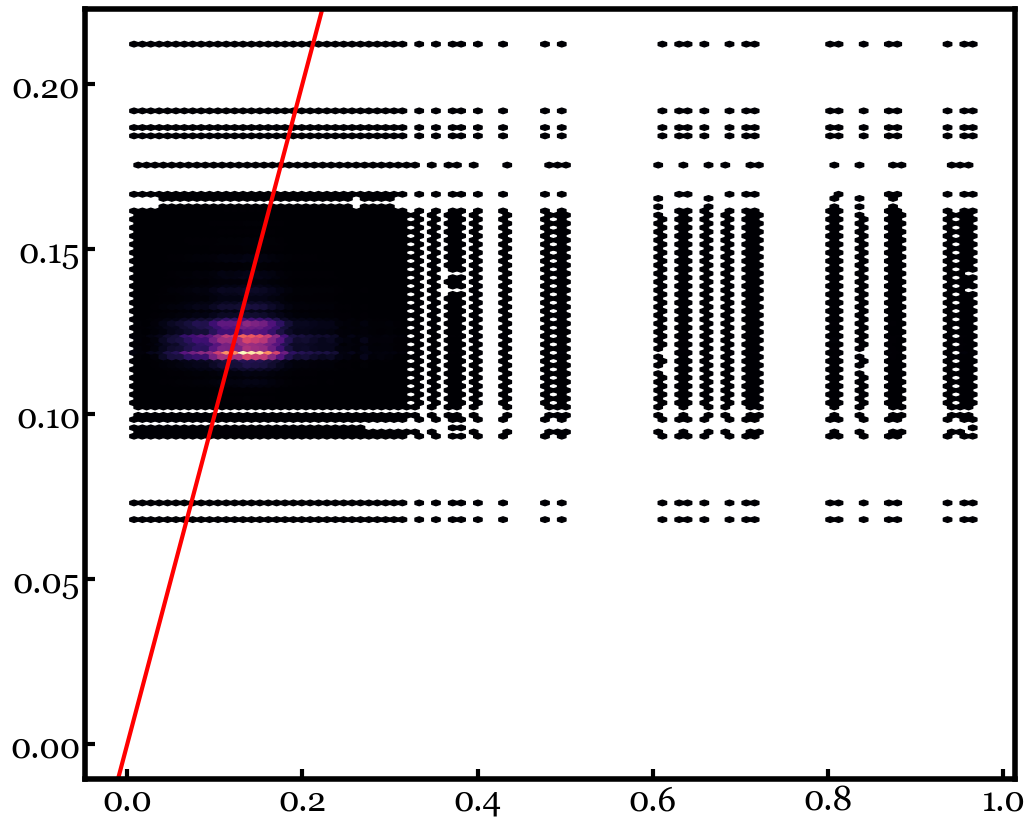

In [14]:
fig = plt.figure()
ax = fig.add_subplot()


ax.hexbin(validation_redshift, estimated_photoz_medians,
          mincnt = 1)
ax.axline((0, 0), slope = 1, color = 'red')

In [ ]:
# Save otputs